# MD simulation of water molecule using MLIP within ESPResSo
In this part of the tutorial, we will perform a MD simulation of the water box generated in part two using MLIP within ESPResSo. All physical parameters follow the procedure described therein, thus, we start rading in the **water.xyz** file.

In [1]:
import zntrack
from ase.io import read

box = read("water.xyz")

Next, we also need to define the model used in the MD simulation.

**Exercise:**
- Define the model using the command `zntrack.from.rev(String)` selecting the appropriate string according to the models trained in part two of this tutorial.

**Hint:**
- To investigate the dependence of the results on the $r_{max}$, the argument passed to `zntrack.from.rev` can be choosen from the following options: `r_max_2_Apax`, `r_max_3_Apax`, `r_max_4_Apax`, `r_max_5_Apax`, `r_max_5_5_Apax`, `r_max_6_Apax`.

In [2]:
# SOLUTION CELL

model = zntrack.from_rev("r_max_5_5_Apax")

By using the generated `model.get_calculater()`, we can obtain the trained interaction calculator `calc`.

In [3]:
calc = model.get_calculator()

box.calc = calc

/tikhome/hkobayashi/.env/tutotial_2025_mlip/lib/python3.12/site-packages/zntrack/state.py:159: UserWarning: The temporary path is not used when neither remote or rev are set.Consider checking for `self.state.remote` and `self.state.rev` whenusing `with node.state.use_tmp_path(): ...` .
  warnings.warn(


Here, we import the necessary ESPResSo features and external modules to combine ESPResSo with MLIP

In [4]:
# ESPResSo imports
import espressomd

# Miscellaneous
import numpy as np
import pint
import tqdm
from espressomd.plugins.ase import ASEInterface

### Unit
In the majority of studies employing machine-learned interatomic potentials, energies are expressed in electronvolts (eV), distances in angstroms, and masses in atomic units (since there are typically also the units of the training data). Although machine-learning algorithms are agnostic to the choice of units, they must be trained within a consistent unit system; thus, it is essential to identify the units being used. Temporal scales are commonly expressed in femtoseconds. Consistent with this practice, ASE adopts the same unit system as its default. In the present tutorial, we employ pint to manage units.

**Exercise:**
- Create an instance of the [`pint.UnitRegistry`](https://pint.readthedocs.io/en/stable/api/base.html#pint.UnitRegistry) to enable unit conversions throughout the tutorial. Assign the instance to the variable `ureg`.

**Hint:**
- You may find it useful to consult the [Tutorial section of pint](https://pint.readthedocs.io/en/stable/getting/tutorial.html#initializing-a-registry) which provides examples of initializing a unit registry.

In [5]:
# SOLUTION CELL

ureg = pint.UnitRegistry()

### Setup System for ESPResSo
All parameters, i.e, system size, the number of particles, the particle positions, etc., follow from the `box` object of ASE. For simplicity, the type of each particle is defined via their respective atomic number.

In [6]:
system = espressomd.System(box_l=box.get_cell().diagonal())
system.periodicity = [True, True, True]
system.time_step = (1.0 * ureg.fs).m_as(
    ((1 * ureg.u * ureg.angstrom**2) / ureg.electron_volt) ** 0.5
)
system.cell_system.skin = 1  # Angstrom
system.part.clear()
for atom in box:
    system.part.add(pos=atom.position, type=atom.number, mass=atom.mass)

To combine ESPResSo and MLIP provided by ASE, we use `espressomd.plugins.ase.ASEInterface`. The arguments of constuctor for `espressomd.plugins.ase.ASEInterface` are `espressomd.System system`, `dictionary type_mapping` and `espressomd.system.part particle_slice`.


ESPResSo can deal with fictitious particle types, does not require physically realistic particle numbers. By contrast, ASE only deals with atomic number. Because of this, we have to define the mapping between the ESPResSo particle types and the ASE atom types. This is done by passing a type_mapping dictionary to the ASEInterface class. An example for such a type map for a water system would be:
An example for such a type map for a water system would be:
```python
type_mapping = {1: 8, 2: 1}
```

e.g., particle type 1 in ESPResSo is mapped to Oxygen (atomic number 8) and particle type 2 is mapped to Hydrogen (atomic number 1).

In this tutorial, for simplicity, we already set the same particle types as the atomic number in ASE.

**Exercise:**
- Create dictionry `type_mapping` to correctoly maps between ASE and ESPResSo according to the current setting. 

**Hint:**
- The system contains only hydrogen(atomic number 1) and oxygen(atomic number 8).

In [7]:
# SOLUTION CELL

type_mapping = {x: x for x in set(box.numbers)}

Using this `type_mapping`, we create `espressomd.plugins.ase.ASEInterface ase_interface`.

In [8]:
system.ase = espressomd.plugins.ase.ASEInterface(
    type_mapping=type_mapping,
)

### Steepest Descent
We use steepset descent to minimize the energy of the system.

In [9]:
system.integrator.set_steepest_descent(
    f_max=(0.1 * ureg.eV / ureg.angstrom).magnitude,
    gamma=4,
    max_displacement=(0.001 * ureg.angstrom).magnitude,
)

MD integration can be performed following these steps for each time step:

1. Update ASE with current particle data: `atoms = system.ase.get()`
2. Set the calculater of ASE as trained interaction calculater `box.calc`
3. Get forces from calculator
4. Set external forces on particles: `system.part.all().ext_force = atoms.get_forces()`
5. Run one integration step

Here, we emphasize that thi procedure assign the force provided by ASE to `particle.ext_force`. In other words, `particle.ext_force` is overwritten at each step. A part from this, all ESPResSo interaction can be used with MLIPs.

**Exercise:**
- Integrate the sytem for 500 steps in total. 

**Hint:**
- In this tutorial, the argument `calculater` should be trained interaction calculater `box.calc`.

It is important to **note** that the `ase_interface` is designed to be flexible: it can work with any MLIP provided through ASE, and is not limited to the trained model used in this tutorial.

In [10]:
# SOLUTION CELL

tbar = tqdm.trange(2500, ncols=120)
for _ in tbar:
    atoms = system.ase.get()
    atoms.calc = box.calc
    system.part.all().ext_force = atoms.get_forces()
    system.integrator.run(1)
    tbar.set_description(f"E_pot: {atoms.get_potential_energy():.3f} eV")

E_pot: -46943.771 eV: 100%|█████████████████████████████████████████████████████████| 2500/2500 [00:49<00:00, 50.93it/s]


### Equilibration
Then, we turn on the Langevin thermostat and run a warmup integration by simplectic Euler algorithm. Here we set the temperature as **298.15** K.

In [11]:
# Symplectic Euler with Langevin Thermostat
system.thermostat.set_langevin(
    kT=(298.15 * ureg.K * ureg.boltzmann_constant).m_as("eV"), gamma=1, seed=42
)
system.integrator.set_symplectic_euler()

In [12]:
tbar = tqdm.trange(100, ncols=120)
count_uncertainty = 0
for idx in tbar:
    atoms = system.ase.get()
    atoms.calc = box.calc
    system.part.all().ext_force = atoms.get_forces()
    system.integrator.run(1)
    # ase_interface.integrate(1, box.calc)
    uncertanity = box.calc.results["forces_uncertainty"].max()
    if uncertanity > 1.0:
        count_uncertainty += 1
    tbar.set_description(f"Uncertainty: {uncertanity:.3f}")
if count_uncertainty > 0:
    print("Model unavailable — SELECT A DIFFERENT MODEL.")

Uncertainty: 0.142: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 57.79it/s]


In [13]:
tbar = tqdm.trange(6000, ncols=120)
count_uncertainty = 0
for idx in tbar:
    atoms = system.ase.get()
    atoms.calc = box.calc
    system.part.all().ext_force = atoms.get_forces()
    system.integrator.run(1)
    tbar.set_description(f"E_pot: {atoms.get_potential_energy():.3f} eV")

E_pot: -46937.128 eV: 100%|█████████████████████████████████████████████████████████| 6000/6000 [01:48<00:00, 55.38it/s]


### Sampling of radial distribution function (RDF)
After warmup calculation, we accumrate the radial distribution function (rdf) of oxygen-oxgen and plot them.

In [14]:
import espressomd.observables

rdfs = []
rdf_bins = 70
r_min = 0.0
r_max = 7  # angstrom
o_ids = system.part.select(type=8).id
rdf_obs = espressomd.observables.RDF(
    ids1=o_ids, ids2=o_ids, n_r_bins=rdf_bins, min_r=r_min, max_r=r_max
)

# Sampling of RDF
sampling_period = 300
tbar = tqdm.trange(sampling_period * 30, ncols=120)
for idx in tbar:
    atoms = system.ase.get()
    atoms.calc = box.calc
    system.part.all().ext_force = atoms.get_forces()
    system.integrator.run(1)
    # ase_interface.integrate(10, box.calc)
    if idx % sampling_period:
        rdfs.append(rdf_obs.calculate())
rdf = np.mean(rdfs, axis=0)
rdf_err = np.std(rdfs, axis=0) / np.sqrt(len(rdfs))
bin_centers = rdf_obs.bin_centers()

100%|███████████████████████████████████████████████████████████████████████████████| 9000/9000 [02:41<00:00, 55.82it/s]


### Plot RDF
As is well known, the first peak in the radial distribution function (RDF) appears at around 3 Å, while the second peak occurs at approximately 4.5–4.8 Å, which is characteristic of the tetrahedral structure.

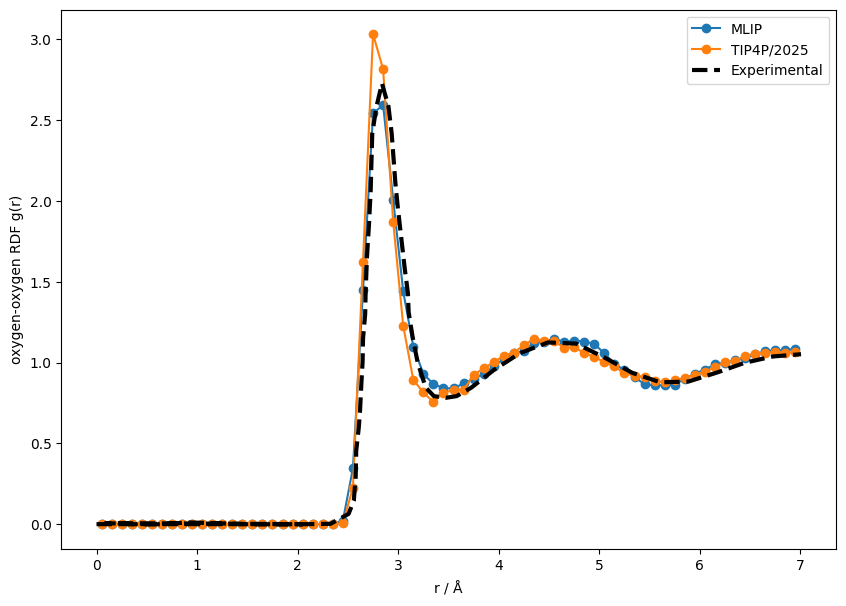

In [15]:
# Plot RDF
import matplotlib.pyplot as plt

data_ex = np.load("data/rdf_experiment.npz")
data_tip4p = np.load("data/rdf_tip4p.npz")

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(bin_centers, rdf, marker="o", label=r"MLIP")
ax.plot(10 * data_tip4p["rs"], data_tip4p["rdf"], marker="o", label="TIP4P/2025")
ax.plot(
    data_ex["rs"],
    data_ex["rdf"],
    ls="dashed",
    lw=3,
    color="black",
    label="Experimental",
)
plt.legend()
plt.xlabel(r"r / $\mathrm{\AA}$")
plt.ylabel("oxygen-oxygen RDF g(r)")
plt.show()

Actually, we have already prepared the RDFs for $r_{max}$ = 2, 3, 4, 5, 5.5 and 6 stored in `.npz` file.

**Exercise:**
- Plot the RDFs for the different values of $r_{max}$ and compare their features. 
- Analyze the origin of the differences observed between the RDFs.

**Hint:**
- The `.npz` files can be loaded using `np.load()`. The filename should be choosen from the following options: `rdf_r_max_2.npz`, `rdf_r_max_3.npz`, `rdf_r_max_4.npz`, `rdf_r_max_5.npz`, `rdf_r_max_5_5.npz`, `rdf_r_max_6.npz`.

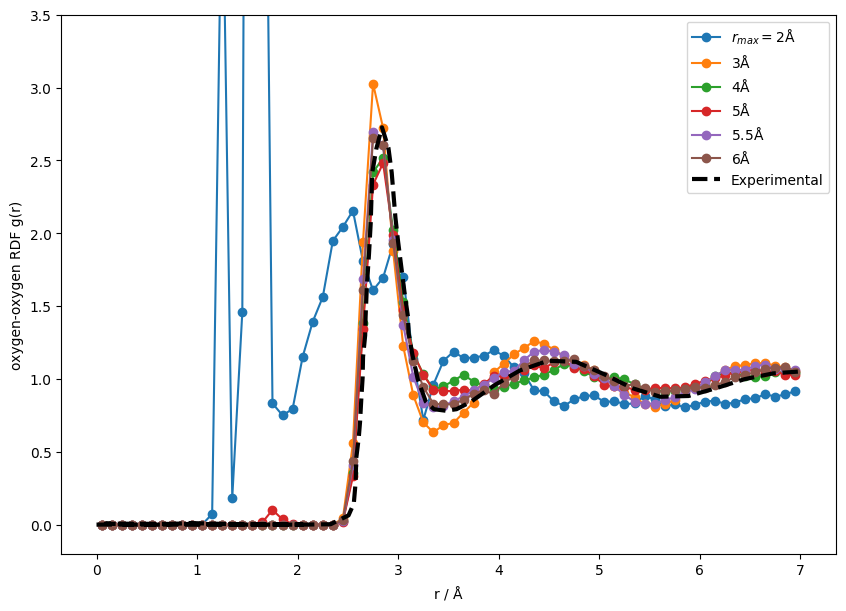

In [16]:
# SOLUTION CELL

# Loading .npz files
data_2 = np.load("data/rdf_rmax_2.npz")
data_3 = np.load("data/rdf_rmax_3.npz")
data_4 = np.load("data/rdf_rmax_4.npz")
data_5 = np.load("data/rdf_rmax_5.npz")
data_5_5 = np.load("data/rdf_rmax_5_5.npz")
data_6 = np.load("data/rdf_rmax_6.npz")

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(data_2["rs"], data_2["rdf"], marker="o", label=r"$r_{max}=2 \mathrm{\AA}$")
ax.plot(data_3["rs"], data_3["rdf"], marker="o", label=r"$3 \mathrm{\AA}$")
ax.plot(data_4["rs"], data_4["rdf"], marker="o", label=r"$4 \mathrm{\AA}$")
ax.plot(data_5["rs"], data_5["rdf"], marker="o", label=r"$5 \mathrm{\AA}$")
ax.plot(data_5_5["rs"], data_5_5["rdf"], marker="o", label=r"$5.5 \mathrm{\AA}$")
ax.plot(data_6["rs"], data_6["rdf"], marker="o", label=r"$6 \mathrm{\AA}$")
ax.plot(
    data_ex["rs"],
    data_ex["rdf"],
    ls="dashed",
    lw=3,
    color="black",
    label="Experimental",
)
ax.set_ylim([-0.2, 3.5])
plt.legend()
plt.xlabel(r"r / $\mathrm{\AA}$")
plt.ylabel("oxygen-oxygen RDF g(r)")
plt.show()

The differences between the RDFs can be attributed to the predictive capabilities of the MLIP. While models with the same cutoff but otherwise different parameters tend to yield similar RDFs, their discrepancies can be explained by errors in the energy and force predictions. In contrast, differences between RDFs from MLIPs with different cutoffs arise from their inherently different predictive abilities, particularly due to the short-sightedness of models with small cutoffs. If a model can only predict based on a cutoff ending after the first coordination shell, long-range interactions must be inferred from short-range structures. Although this can produce reasonable results - and is one of the reasons why MLIPs often perform so well- a very short cutoff will lead to incorrect structural properties.

Because our MLIP learns all interactions, it can happen that minimum bond distances are not obeyed, leading to unphysical behavior in the simulation that are reflected in the RDF plots. Although this can be mitigated by including short-range two-body potential terms, fundamentally, if such behavior occurs, the model parameters or training data should be improved.